> Benjamin Nikholas

> Data Science / JCSDOL-014

> Modul 3 - Tugas 18

> 23 Juli 2024
---
---

In [10]:
import pandas as pd
pd.set_option('display.max_columns', 30)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Target : LeaveOrNot 

In [4]:
df = pd.read_csv('Employee.csv')
df.info()
display(df.head(5))

X = df.drop(columns = 'LeaveOrNot')
y = df['LeaveOrNot']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


Lakukan Feature Selection

In [6]:
# Encode categorical features for chi-squared test
X_categ_cols = X.select_dtypes('object').columns

label_encoders = {}
for cols in X_categ_cols:
    le = LabelEncoder()
    X[cols] = le.fit_transform(df[cols])
    label_encoders[cols] = le

In [7]:
chi2_selector = SelectKBest(score_func = chi2, 
                            k = 'all')
chi2_selector.fit(X, y)
chi2_scores = chi2_selector.scores_

# Get feature names and scores
features = X.columns
feature_scores = pd.DataFrame({'Feature': features, 
                               'Score': chi2_scores}).sort_values(
                                   by = 'Score', 
                                   ascending = False
                               ).reset_index(drop = True)
                               
# Select features
feature_select = feature_scores.iloc[:5]['Feature'].values
X_feat_select = df[feature_select]
X_feat_select.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   City         4653 non-null   object
 1   Gender       4653 non-null   object
 2   Education    4653 non-null   object
 3   EverBenched  4653 non-null   object
 4   PaymentTier  4653 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 181.9+ KB


Lakukan Feature Engineering 

In [8]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), X_feat_select.select_dtypes(include = 'int64').columns),
        ('cat', OneHotEncoder(), X_feat_select.select_dtypes(exclude = 'int64').columns)
    ])

X_processed = preprocessor.fit_transform(X_feat_select)

X_processed = pd.DataFrame(X_processed, 
                           columns = preprocessor.get_feature_names_out())

Split data menjadi Train 75% dan Test 25% 

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y,
                                                    train_size = 0.75,
                                                    random_state = 1)

Lakukan Modelling menggunakan Decision Tree

In [15]:
# Decision Tree Model
model = DecisionTreeClassifier(random_state = None)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7534364261168385
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.96      0.83       737
           1       0.86      0.39      0.54       427

    accuracy                           0.75      1164
   macro avg       0.79      0.68      0.69      1164
weighted avg       0.78      0.75      0.72      1164



Lakukan Tuning untuk Hyper Parameter dari Decision Tree 

In [19]:
from sklearn.model_selection import GridSearchCV

# Menentukan parameter grid
param_grid = {
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Menginisialisasi GridSearchCV
grid_search = GridSearchCV(estimator = DecisionTreeClassifier(random_state = None),
                           param_grid=param_grid,
                           cv = 5,
                           scoring = 'accuracy',
                           n_jobs = -1)

# Melakukan pencarian grid pada data latih
grid_search.fit(X_train, y_train)

# Mendapatkan hyperparameter terbaik
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Melatih model dengan hyperparameter terbaik
best_dt_model = grid_search.best_estimator_
y_best_pred = best_dt_model.predict(X_test)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 20}


Lakukan Evaluation Metrics Comparison 

In [21]:
# Evaluasi model terbaik
print("Best Model Accuracy:", accuracy_score(y_test, y_best_pred).round(3))
print("Best Model Classification Report:\n", classification_report(y_test, y_best_pred))

Best Model Accuracy: 0.752
Best Model Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.96      0.83       737
           1       0.86      0.39      0.53       427

    accuracy                           0.75      1164
   macro avg       0.79      0.67      0.68      1164
weighted avg       0.78      0.75      0.72      1164



Tentukan Features mana yg paling penting 

In [37]:
feature_importance = pd.DataFrame({
    'Feature': preprocessor.get_feature_names_out(),
    'Importance': best_dt_model.feature_importances_
}).sort_values(by = 'Importance',
               ascending = False).reset_index(drop = True)

display(feature_importance)

,Feature,Importance
0,cat__City_Pune,0.263739
1,num__PaymentTier,0.210334
2,cat__Education_Masters,0.156996
3,cat__Education_Bachelors,0.110856
4,cat__Gender_Male,0.104262
5,cat__City_Bangalore,0.051342
6,cat__Gender_Female,0.037669
7,cat__City_New Delhi,0.029332
8,cat__EverBenched_Yes,0.018232
9,cat__EverBenched_No,0.015426


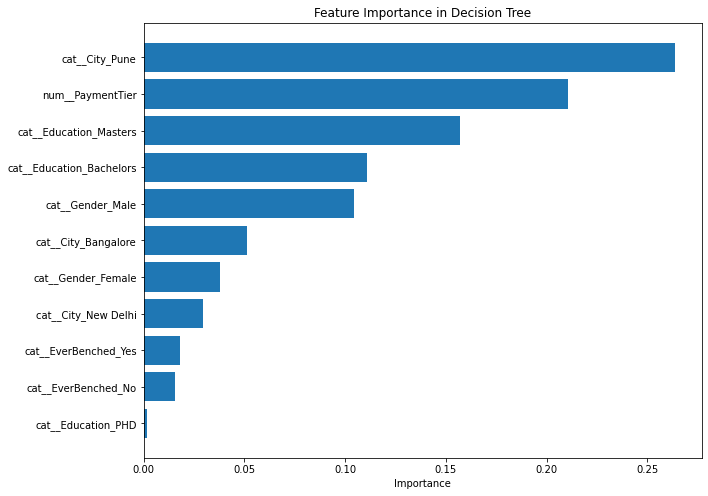

In [38]:
plt.figure(figsize = (10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()
plt.show()